# STAC + VirtualiZarr

End-to-end example: query a STAC API for Landsat COGs in California spanning
two adjacent UTM zones (10N and 11N), virtualize them into an Icechunk store
with zarr-datafusion-search metadata, and merge them into a single grid using
`merge(datafusion=True)`.

The UTM zone boundary runs roughly along **-120° longitude** through the
Sierra Nevada. We pick a bbox around Lake Tahoe that straddles both zones.


**AWS credentials:** This notebook reads from the public `usgs-landsat` bucket
(requester-pays) in `us-west-2`. You need valid AWS credentials configured.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import zarr
from affine import Affine
from rasterix import RasterIndex

from lazymerge.merge import merge

warnings.filterwarnings("ignore")
xr.set_options(display_expand_indexes=True)

## 1. Configure cloud storage

Landsat Collection 2 Level-2 data lives in the `usgs-landsat` S3 bucket
(requester-pays, `us-west-2`).

In [2]:
import boto3
from obstore.store import S3Store
from obspec_utils.registry import ObjectStoreRegistry
from obstore.auth.boto3 import Boto3CredentialProvider

scheme = "s3://"
bucket = "usgs-landsat"
region = "us-west-2"

session = boto3.Session()
object_store = S3Store(
    bucket=bucket,
    region=region,
    request_payer=True,
    credential_provider=Boto3CredentialProvider(session=session),
)
registry = ObjectStoreRegistry({f"{scheme}{bucket}": object_store})

## 2. Set up Icechunk repository

Icechunk provides a versioned zarr store that supports virtual chunk references
back to the original COG files on S3.

In [3]:
import icechunk

location = "data/icechunk_california"
storage = icechunk.local_filesystem_storage(location)

config = icechunk.RepositoryConfig.default()
s3_chunk_store = icechunk.s3_store(
    region=region,
    requester_pays=True,
)
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(f"{scheme}{bucket}/", s3_chunk_store)
)
credentials = icechunk.containers_credentials(
    {f"{scheme}{bucket}/": icechunk.s3_credentials(from_env=True)}
)
repo = icechunk.Repository.open_or_create(
    storage=storage, config=config, authorize_virtual_chunk_access=credentials
)
ic_session = repo.writable_session("main")

  2026-05-20T17:55:08.515883Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



## 3. Ingest STAC search results

Query Earth Search for Landsat Collection 2 Level-2 scenes around Lake Tahoe.
The bbox **(-121.5, 38.5, -118.5, 40.5)** spans the UTM 10N / 11N boundary
at -120° longitude, so we get scenes in both zones.

We request 6 scenes and ingest the `red`, `green`, and `blue` asset hrefs.

In [4]:
from zarr_datafusion_search import ingest_stac_search

rows = await ingest_stac_search(
    url="https://earth-search.aws.element84.com/v1",
    session=ic_session,
    collections=["landsat-c2-l2"],
    bbox=(-121.5, 38.5, -118.5, 40.5),
    max_items=6,
    datetime="2025-10-01/2025-10-15",
    asset_hrefs=["red", "green", "blue"],
)
rows

6

## 4. Query metadata with DataFusion

Use DataFusion SQL to inspect the ingested metadata and verify we have
scenes in both UTM zones.

In [4]:
from datafusion import SessionContext
from geodatafusion import register_all

from zarr_datafusion_search import ZarrTable

ic_session = repo.writable_session("main")
zarr_table = await ZarrTable.from_icechunk(session=ic_session, group_path="/meta")

ctx = SessionContext()
register_all(ctx)
ctx.register_table_provider("meta", zarr_table)

df = ctx.sql(
    'SELECT * FROM meta ORDER BY datetime'
)
df

asset_blue,asset_green,asset_red,bbox,created,datetime,description,earthsearch:payload_id,eo:cloud_cover,grid:code,gsd,id,landsat:cloud_cover_land,landsat:collection_category,landsat:collection_number,landsat:correction,landsat:product_generated,landsat:scene_id,landsat:wrs_path,landsat:wrs_row,landsat:wrs_type,platform,proj:epsg,sci:doi,shape_x,shape_y,transform_0,transform_1,transform_2,transform_3,transform_4,transform_5,updated,view:off_nadir,view:sun_azimuth,view:sun_elevation
s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/032/LC09_L2SP_043032_20251011_20251012_02_T1/LC09_L2SP_043032_20251011_20251012_02_T1_SR_B2.TIF...,s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/032/LC09_L2SP_043032_20251011_20251012_02_T1/LC09_L2SP_043032_20251011_20251012_02_T1_SR_B3.TIF...,s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/032/LC09_L2SP_043032_20251011_20251012_02_T1/LC09_L2SP_043032_20251011_20251012_02_T1_SR_B4.TIF...,b'\x01\x03\x00\x00\x00\x0b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xb6f+/\xf9J^\xc0m\x1bFA\xf0\x9aC@\x13\xbb\xb6\xb7[\x93]\xc0m\x1bFA\xf0\x9aC@\x13\xbb\xb6\xb7[\x93]\xc0\xe6Z\xb4\x00m\xb7D@\xb6f+/\xf9J^\xc0\xe6Z\xb4\x00m\xb7D@\xb6f+/\xf9J^\xc0m\x1bFA\xf0\x9aC@'...,2025-10-12 17:19:47.309002025-10-12 17:19:47.309000...,2025-10-11 18:39:27.987002025-10-11 18:39:27.987000...,Landsat Collection 2 LeveLandsat Collection 2 Level-2...,usgs-landsat-c2l2/workflousgs-landsat-c2l2/workflow-landsat-to-stac/d486616635101d2c0a63564d8f39256c...,30.47,WRS2-043032,30,LC09_L2SP_043032_20251011LC09_L2SP_043032_20251011_02_T1...,30.47,T1,02,L2SP,2025-10-12T16:19:40Z,LC90430322025284LGN00,043,032,2,landsat-9,32611,10.5066/P9OGBGM6,7901,8011,30.0,0.0,150885.0,0.0,-30.0,4587915.0,2025-10-12 17:19:47.309002025-10-12 17:19:47.309000...,0,158.43982425,39.96946877
s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/033/LC09_L2SP_043033_20251011_20251012_02_T1/LC09_L2SP_043033_20251011_20251012_02_T1_SR_B2.TIF...,s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/033/LC09_L2SP_043033_20251011_20251012_02_T1/LC09_L2SP_043033_20251011_20251012_02_T1_SR_B3.TIF...,s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/033/LC09_L2SP_043033_20251011_20251012_02_T1/LC09_L2SP_043033_20251011_20251012_02_T1_SR_B4.TIF...,"b'\x01\x03\x00\x00\x00\x0b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xb1mQf\x83_^\xc0\x0f\x80\xb8\xabW\xe9B@+P\x8b\xc1\xc3\xb2]\xc0\x0f\x80\xb8\xabW\xe9B@+P\x8b\xc1\xc3\xb2]\xc0\xddBW""P\xfbC@\xb1mQf\x83_^\xc0\xddBW""P\xfbC@\xb1mQf\x83_^\xc0\x0f\x80\xb8\xabW\xe9B@'...",2025-10-12 18:07:33.021002025-10-12 18:07:33.021000...,2025-10-11 18:39:51.878002025-10-11 18:39:51.878000...,Landsat Collection 2 LeveLandsat Collection 2 Level-2...,usgs-landsat-c2l2/workflousgs-landsat-c2l2/workflow-landsat-to-stac/b951a42cd969ef0d347805e20a00c0fb...,9.05,WRS2-043033,30,LC09_L2SP_043033_20251011LC09_L2SP_043033_20251011_02_T1...,9.05,T1,02,L2SP,2025-10-12T16:32:40Z,LC90430332025284LGN00,043,033,2,landsat-9,32610,10.5066/P9OGBGM6,7581,7701,30.0,0.0,632385.0,0.0,-30.0,4425015.0,2025-10-12 18:07:33.021002025-10-12 18:07:33.021000...,0,157.54660497,41.19354606
s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/034/LC09_L2SP_043034_20251011_20251012_02_T1/LC09_L2SP_043034_20251011_20251012_02_T1_SR_B2.TIF...,s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/034/LC09_L2SP_043034_20251011_20251012_02_T1/LC09_L2SP_043034_20251011_20251012_02_T1_SR_B3.TIF...,s3://usgs-landsat/collects3://usgs-landsat/collection02/level-2/standard/oli-tirs/2025/043/034/LC09_L2SP_043034_20251011_20251012_02_T1/LC09_L2SP_043034_20251011_20251012_02_T1_SR_B4.TIF...,b'\x01\x03\x00\x00\x00\x0b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00

## 5. Virtualize COGs and write conventions

For each scene, use VirtualiZarr to create virtual zarr references to the
original COG overviews on S3, then write zarr conventions metadata
(multiscales, spatial, proj) to the Icechunk store.

In [6]:
from typing import Any, MutableMapping

from rasterio.warp import transform_bounds
from shapely import wkb
from virtual_tiff import VirtualTIFF
from virtualizarr import open_virtual_dataset

from lazymerge.conventions import ProjAttrs, SpatialAttrs, write_proj, write_spatial


def write_multiscales(overviews: int, attrs: MutableMapping[str, Any]):
    layout = []
    factor = 2
    for overview in range(overviews):
        if overview == 0:
            config = {"asset": str(overview)}
        else:
            scale = float(factor**overview)
            config = {
                "asset": str(overview),
                "derived_from": str(overview - 1),
                "factors": [factor, factor],
                "transform": {
                    "scale": [scale, scale],
                    "translation": [0.0, 0.0],
                },
            }
        layout.append(config)
    attrs["multiscales"] = {"layout": layout}


def write_virtualizarr_data(
    id: str, assets: dict[str, str], overviews: int, session, registry
):
    for key, asset in assets.items():
        for overview in range(overviews):
            group = f"{id}/{key}/{overview}"
            ds = open_virtual_dataset(
                url=asset, registry=registry, parser=VirtualTIFF(ifd=overview)
            )
            ds.vz.to_icechunk(store=session.store, group=group)


def write_conventions(row: dict[str, Any], overviews: int, session, bands: list[str]):
    store = session.store
    item_id = row["id"]

    # Compute projected bbox once (same for all overviews)
    geom = wkb.loads(row["bbox"])
    bbox_4326 = [*geom.bounds]
    proj_code = row["proj:epsg"]
    projected_bbox = transform_bounds("EPSG:4326", proj_code, *bbox_4326)

    # Base transform from ingest metadata
    base_transform = (
        row["transform_0"], row["transform_1"], row["transform_2"],
        row["transform_3"], row["transform_4"], row["transform_5"],
    )
    base_shape = (row["shape_y"], row["shape_x"])
    proj_attrs = ProjAttrs(code=f"EPSG:{proj_code}")

    # Write spatial+proj on the item group (for source discovery)
    item_group = zarr.open_group(store, path=f"/{item_id}", zarr_format=3)
    write_spatial(
        item_group,
        SpatialAttrs(
            dimensions=["y", "x"],
            transform=base_transform,
            bbox=projected_bbox,
            shape=base_shape,
        ),
    )
    write_proj(item_group, proj_attrs)

    for band in bands:
        # Write multiscales convention on each band group
        band_group = zarr.open_group(store, path=f"/{item_id}/{band}", zarr_format=3)
        write_multiscales(overviews=overviews, attrs=band_group.attrs)

        # Write spatial+proj on each overview array
        for level in range(overviews):
            factor = 2 ** level
            ovr_res_x = base_transform[0] * factor
            ovr_res_y = base_transform[4] * factor
            ovr_transform = (
                ovr_res_x, base_transform[1], base_transform[2],
                base_transform[3], ovr_res_y, base_transform[5],
            )

            # Open the VirtualiZarr array (group-wrapped: {level}/{level})
            level_group = zarr.open_group(
                store, path=f"/{item_id}/{band}/{level}", zarr_format=3
            )
            for name, member in level_group.members():
                if isinstance(member, zarr.Array):
                    arr = member
                    break
            else:
                continue

            ovr_shape = arr.shape
            write_spatial(
                arr,
                SpatialAttrs(
                    dimensions=["y", "x"],
                    transform=ovr_transform,
                    bbox=projected_bbox,
                    shape=ovr_shape,
                ),
            )
            write_proj(arr, proj_attrs)

In [7]:
overviews = 7
bands = ["red", "green", "blue"]

for row in df.to_arrow_table().to_pylist():
    assets = {
        "red": row["asset_red"],
        "green": row["asset_green"],
        "blue": row["asset_blue"],
    }
    ic_session = repo.writable_session("main")
    write_virtualizarr_data(
        id=row["id"],
        assets=assets,
        overviews=overviews,
        session=ic_session,
        registry=registry,
    )
    write_conventions(row=row, overviews=overviews, session=ic_session, bands=bands)
    message = ic_session.commit(row["id"])
    print(f"Committed {row['id']} (EPSG:{row['proj:epsg']})")

Committed LC09_L2SP_043032_20251011_02_T1 (EPSG:32611)
Committed LC09_L2SP_043033_20251011_02_T1 (EPSG:32610)
Committed LC09_L2SP_043034_20251011_02_T1 (EPSG:32610)
Committed LC08_L2SP_042032_20251012_02_T1 (EPSG:32611)
Committed LC08_L2SP_042033_20251012_02_T1 (EPSG:32611)
Committed LC08_L2SP_042034_20251012_02_T1 (EPSG:32611)


## 6. Inspect the store

Verify the Icechunk store has the expected structure: `/meta` group with
columnar arrays, plus per-scene groups with band subgroups and overviews.

In [8]:
ic_session = repo.writable_session("main")
root = zarr.open(ic_session.store)
root.tree()

/
├── LC08_L2SP_042032_20251012_02_T1
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (7931, 7811) uint16
│   │   ├── 1
│   │   │   └── 1 (3966, 3906) uint16
│   │   ├── 2
│   │   │   └── 2 (1983, 1953) uint16
│   │   ├── 3
│   │   │   └── 3 (992, 977) uint16
│   │   ├── 4
│   │   │   └── 4 (496, 489) uint16
│   │   ├── 5
│   │   │   └── 5 (248, 245) uint16
│   │   └── 6
│   │       └── 6 (124, 123) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (7931, 7811) uint16
│   │   ├── 1
│   │   │   └── 1 (3966, 3906) uint16
│   │   ├── 2
│   │   │   └── 2 (1983, 1953) uint16
│   │   ├── 3
│   │   │   └── 3 (992, 977) uint16
│   │   ├── 4
│   │   │   └── 4 (496, 489) uint16
│   │   ├── 5
│   │   │   └── 5 (248, 245) uint16
│   │   └── 6
│   │       └── 6 (124, 123) uint16
│   └── red
│       ├── 0
│       │   └── 0 (7931, 7811) uint16
│       ├── 1
│       │   └── 1 (3966, 3906) uint16
│       ├── 2
│       │   └── 2 (1983, 1953) uint16
│       ├── 3
│       │   └── 3 (992, 977) uint16
│       ├── 4
│       │   └── 4 (496, 489) uint16
│       ├── 5
│       │   └── 5 (248, 245) uint16
│       └── 6
│           └── 6 (124, 123) uint16
├── LC08_L2SP_042033_20251012_02_T1
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (7941, 7811) uint16
│   │   ├── 1
│   │   │   └── 1 (3971, 3906) uint16
│   │   ├── 2
│   │   │   └── 2 (1986, 1953) uint16
│   │   ├── 3
│   │   │   └── 3 (993, 977) uint16
│   │   ├── 4
│   │   │   └── 4 (497, 489) uint16
│   │   ├── 5
│   │   │   └── 5 (249, 245) uint16
│   │   └── 6
│   │       └── 6 (125, 123) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (7941, 7811) uint16
│   │   ├── 1
│   │   │   └── 1 (3971, 3906) uint16
│   │   ├── 2
│   │   │   └── 2 (1986, 1953) uint16
│   │   ├── 3
│   │   │   └── 3 (993, 977) uint16
│   │   ├── 4
│   │   │   └── 4 (497, 489) uint16
│   │   ├── 5
│   │   │   └── 5 (249, 245) uint16
│   │   └── 6
│   │       └── 6 (125, 123) uint16
│   └── red
│       ├── 0
│       │   └── 0 (7941, 7811) uint16
│       ├── 1
│       │   └── 1 (3971, 3906) uint16
│       ├── 2
│       │   └── 2 (1986, 1953) uint16
│       ├── 3
│       │   └── 3 (993, 977) uint16
│       ├── 4
│       │   └── 4 (497, 489) uint16
│       ├── 5
│       │   └── 5 (249, 245) uint16
│       └── 6
│           └── 6 (125, 123) uint16
├── LC08_L2SP_042034_20251012_02_T1
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (7941, 7821) uint16
│   │   ├── 1
│   │   │   └── 1 (3971, 3911) uint16
│   │   ├── 2
│   │   │   └── 2 (1986, 1956) uint16
│   │   ├── 3
│   │   │   └── 3 (993, 978) uint16
│   │   ├── 4
│   │   │   └── 4 (497, 489) uint16
│   │   ├── 5
│   │   │   └── 5 (249, 245) uint16
│   │   └── 6
│   │       └── 6 (125, 123) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (7941, 7821) uint16
│   │   ├── 1
│   │   │   └── 1 (3971, 3911) uint16
│   │   ├── 2
│   │   │   └── 2 (1986, 1956) uint16
│   │   ├── 3
│   │   │   └── 3 (993, 978) uint16
│   │   ├── 4
│   │   │   └── 4 (497, 489) uint16
│   │   ├── 5
│   │   │   └── 5 (249, 245) uint16
│   │   └── 6
│   │       └── 6 (125, 123) uint16
│   └── red
│       ├── 0
│       │   └── 0 (7941, 7821) uint16
│       ├── 1
│       │   └── 1 (3971, 3911) uint16
│       ├── 2
│       │   └── 2 (1986, 1956) uint16
│       ├── 3
│       │   └── 3 (993, 978) uint16
│       ├── 4
│       │   └── 4 (497, 489) uint16
│       ├── 5
│       │   └── 5 (249, 245) uint16
│       └── 6
│           └── 6 (125, 123) uint16
├── LC09_L2SP_043032_20251011_02_T1
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (8011, 7901) uint16
│   │   ├── 1
│   │   │   └── 1 (4006, 3951) uint16
│   │   ├── 2
│   │   │   └── 2 (2003, 1976) uint16
│   │   ├── 3
│   │   │   └── 3 (1002, 988) uint16
│   │   ├── 4
│   │   │   └── 4 (501, 494) uint16
│   │   ├── 5
│   │   │   └── 5 (251, 247) uint16
│   │   └── 6
│   │       └── 6 (126, 124) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (8011, 7901) uint16
│   │   ├── 1
│   │   │   └── 1 (4006, 3951) uint16
│   │   ├── 2
│   │   │   └── 2 (2003, 1976) 

## 7. Merge

Define a target grid in **UTM 11N** (EPSG:32611) covering the Lake Tahoe area.
Sources in UTM 10N will be reprojected on the fly during merge.

We use `band="red"` to merge the red band, and `sortby="id"` to control
compositing order.

In [13]:
result_arr, result_spatial, result_proj = merge(
    store=ic_session.store,
    crs="EPSG:32611",
    bbox=(200000.0, 4260000.0, 340000.0, 4490000.0),
    resolution=30.0,
    chunk_size=(1024, 1024),
    band="red",
    datafusion=True,
    sortby="id",
    nodata=0,
)

## 7b. Explain plan (dry-run)

Before running compute, use `explain()` to see exactly what source regions
each target chunk would read — without fetching any pixel data. This helps
diagnose performance and verify overview selection.

In [14]:
from lazymerge.explain import explain

plan = explain(
    store=ic_session.store,
    crs="EPSG:32611",
    bbox=(200000.0, 4260000.0, 340000.0, 4490000.0),
    resolution=30.0,
    chunk_size=(1024, 1024),
    band="red",
    datafusion=True,
    sortby="id",
    nodata=0,
)
print(plan.summary())

=== ExplainPlan ===
CRS:        EPSG:32611  |  Resolution: 30.0 units/px  |  Grid: 4667 x 7667 px
Band:       red
Resampling: nearest  |  Nodata: 0
Chunks:     1024 x 1024 px -> 5x8 spatial tiles

Total chunk reads:      40 (5x8 spatial tiles)
Total source reads:     103
Chunks with 0 sources:     0 (0.0%)
Chunks with 1 source:      6 (15.0%)
Chunks with 2+ sources:   34 (85.0%)
Max sources per chunk:  4
Overview levels:        0: 103
Avg read window:        870 x 885 px


In [15]:
plan.to_dataframe()

,chunk_row,chunk_col,chunk_height,chunk_width,n_source_reads,source_path,source_crs,overview_path,native_resolution,overview_resolution,region_row_start,region_row_end,region_col_start,region_col_end,region_height,region_width
0,0,0,1024,1024,1,LC09_L2SP_043032_20251011_02_T1/red/0,EPSG:32611,0,30.0,30.0,3263,4288,1637,2662,1025,1025
1,0,1,1024,1024,1,LC09_L2SP_043032_20251011_02_T1/red/0,EPSG:32611,0,30.0,30.0,3263,4288,2661,3686,1025,1025
2,0,2,1024,1024,2,LC08_L2SP_042032_20251012_02_T1/red/0,EPSG:32611,0,30.0,30.0,3123,4148,0,250,1025,250
3,0,2,1024,1024,2,LC09_L2SP_043032_20251011_02_T1/red/0,EPSG:32611,0,30.0,30.0,3263,4288,3685,4710,1025,1025
4,0,3,1024,1024,2,LC08_L2SP_042032_20251012_02_T1/red/0,EPSG:32611,0,30.0,30.0,3123,4148,249,1274,1025,1025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,7,3,499,1024,4,LC09_L2SP_043033_20251011_02_T1/red/0,EPSG:32610,0,30.0,30.0,4818,5384,6076,7133,566,1057
99,7,3,499,1024,4,LC09_L2SP_043034_20251011_02_T1/red/0,EPSG:32610,0,30.0,30.0,0,64,7196,7591,64,395
100,7,4,499,571,3,LC08_L2SP_042033_20251012_02_T1/red/0,EPSG:32611,0,30.0,30.0,5031,5531,2633,3205,500,572
101,7,4,499,571,3,LC08_L2SP_042034_20251012_02_T1/red/0,EPSG:32611,0,30.0,30.0,0,271,4013,4585,271,572


## 8. Open the lazy Cubed array with xarray

In [16]:
da = xr.DataArray(result_arr, dims=["y", "x"])

affine = Affine(*result_spatial.transform)
raster_idx = RasterIndex.from_transform(
    affine=affine,
    width=da.sizes["x"],
    height=da.sizes["y"],
    x_dim="x",
    y_dim="y",
    crs=result_proj.code,
)
coords = xr.Coordinates.from_xindex(raster_idx)
da = da.assign_coords(coords)
da = da.proj.assign_crs(spatial_ref=result_proj.code, allow_override=True)
da

<xarray.DataArray 'array-006' (y: 7667, x: 4667)> Size: 143MB
cubed.Array<array-006, shape=(7667, 4667), dtype=float32, chunks=((1024, 1024, 1024, 1024, 1024, 1024, 1024, 499), (1024, 1024, 1024, 1024, 571))>
Coordinates:
  * y            (y) float64 61kB 4.49e+06 4.49e+06 ... 4.26e+06 4.26e+06
  * x            (x) float64 37kB 2e+05 2e+05 2.001e+05 ... 3.4e+05 3.4e+05
  * spatial_ref  int64 8B 0
Indexes:
  ┌ x            RasterIndex (crs=EPSG:32611)
  └ y
    spatial_ref  CRSIndex (crs=EPSG:32611)

## 9. Compute and visualize

Compute the result and plot it.

In [17]:
da = da.compute()
da

<xarray.DataArray 'array-006' (y: 7667, x: 4667)> Size: 143MB
array([[29472., 28274., 26576., ..., 12928., 12824., 13055.],
       [24593., 23967., 20958., ..., 13376., 12967., 13023.],
       [16734., 17361., 15448., ..., 13352., 13271., 13246.],
       ...,
       [ 7672.,  8198.,  8366., ..., 11542., 11750., 11939.],
       [ 7704.,  8113.,  8495., ..., 11527., 11862., 12243.],
       [ 7887.,  8010.,  8582., ..., 11931., 11721., 12248.]],
      shape=(7667, 4667), dtype=float32)
Coordinates:
  * y            (y) float64 61kB 4.49e+06 4.49e+06 ... 4.26e+06 4.26e+06
  * x            (x) float64 37kB 2e+05 2e+05 2.001e+05 ... 3.4e+05 3.4e+05
  * spatial_ref  int64 8B 0
Indexes:
  ┌ x            RasterIndex (crs=EPSG:32611)
  └ y
    spatial_ref  CRSIndex (crs=EPSG:32611)

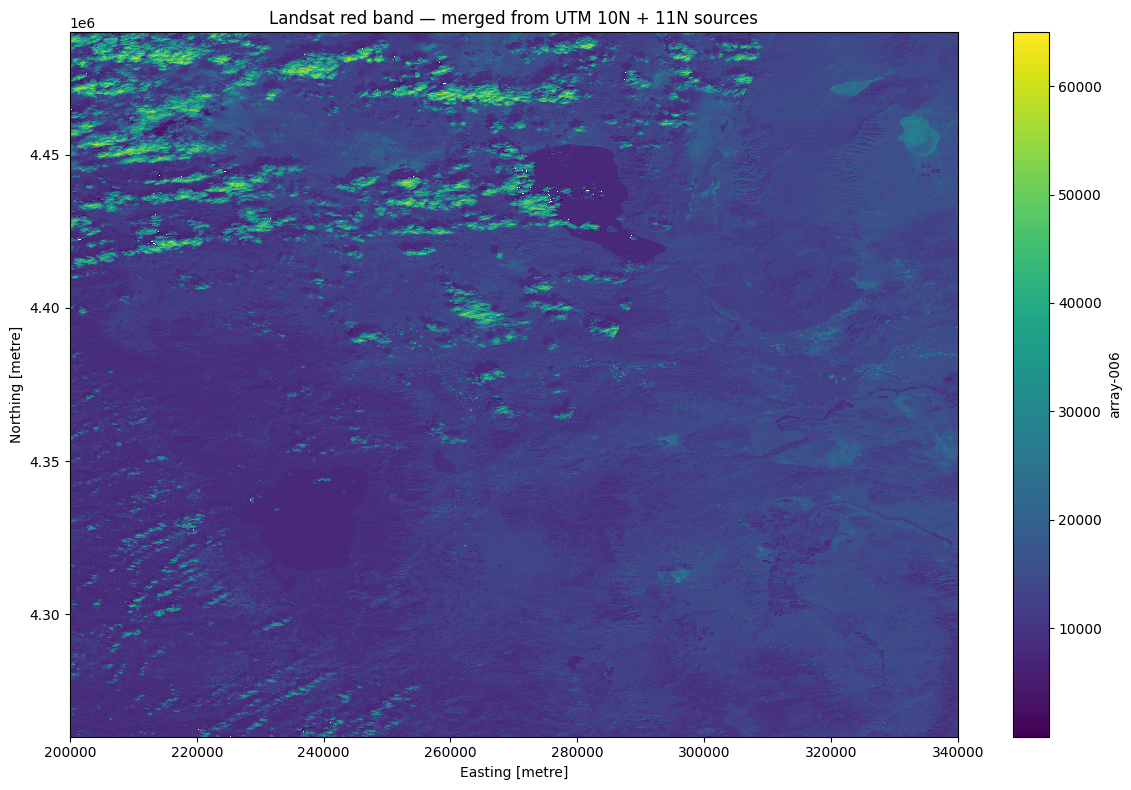

In [18]:
da.plot(figsize=(12, 8), add_colorbar=True)
plt.title("Landsat red band — merged from UTM 10N + 11N sources")
plt.tight_layout();

## 10. Use additional SQL filters

We can also add additional SQL filters to narrow the criteria for source granules

In [19]:
result_arr, result_spatial, result_proj = merge(
    store=ic_session.store,
    crs="EPSG:32611",
    bbox=(200000.0, 4260000.0, 340000.0, 4490000.0),
    resolution=30.0,
    chunk_size=(1024, 1024),
    band="red",
    datafusion=True,
    sortby="id",
    nodata=0,
    sql_filter='"eo:cloud_cover" < 30',
)

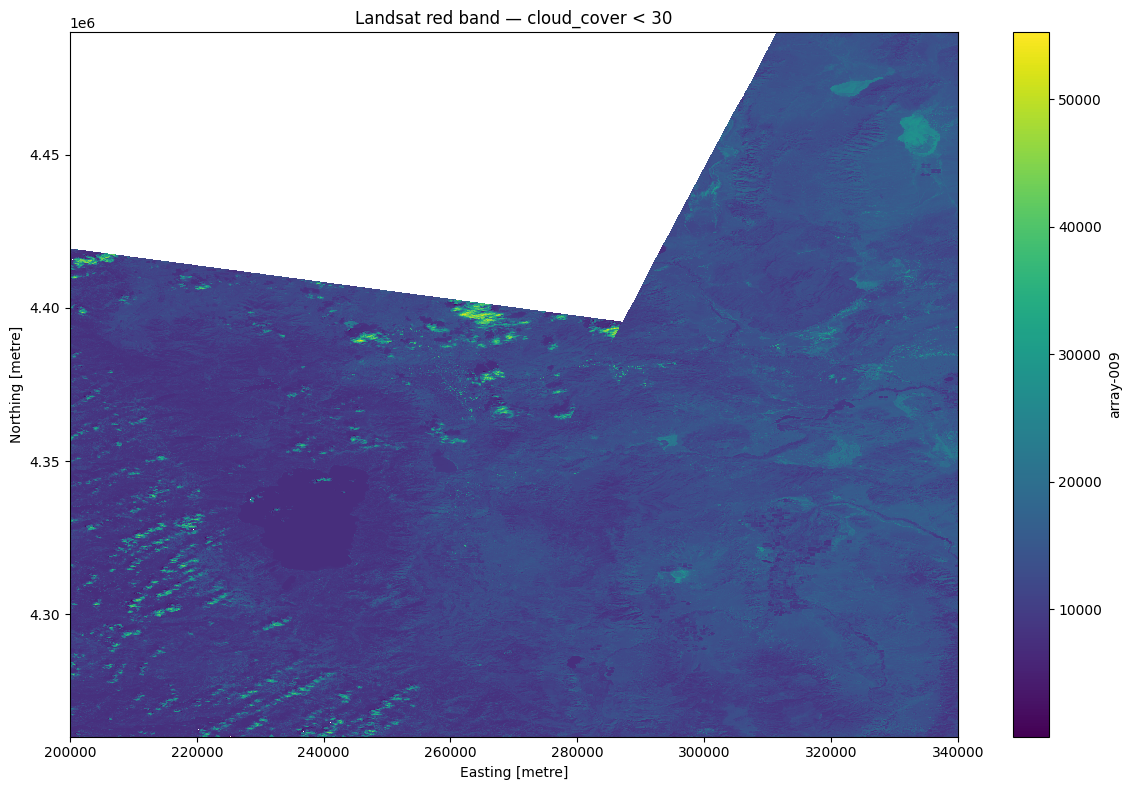

In [21]:
da = xr.DataArray(result_arr, dims=["y", "x"])

affine = Affine(*result_spatial.transform)
raster_idx = RasterIndex.from_transform(
    affine=affine,
    width=da.sizes["x"],
    height=da.sizes["y"],
    x_dim="x",
    y_dim="y",
    crs=result_proj.code,
)
coords = xr.Coordinates.from_xindex(raster_idx)
da = da.assign_coords(coords)
da = da.proj.assign_crs(spatial_ref=result_proj.code, allow_override=True)
da.plot(figsize=(12, 8), add_colorbar=True)
plt.title("Landsat red band — cloud_cover < 30")
plt.tight_layout();